# EDA - Churn de clientes e-commerce

**Objetivo de negocio:** entender que clientes tienen mas riesgo de abandonar la empresa y que senales tempranas podria usar el gerente comercial para priorizar acciones de retencion.

Este notebook corresponde a la entrega de EDA. No se entrena ningun modelo predictivo todavia: primero se valida la calidad de los datos, se exploran patrones y se formulan hipotesis de negocio.

## 1. Contexto y pregunta

La empresa de e-commerce quiere responder dos preguntas:

- **Podemos detectar senales de clientes que estan por irse antes de que dejen de comprar?**
- **Por que nos dejan?**

En este dataset, `Churn = 1` significa que el cliente se fue y `Churn = 0` significa que sigue activo. Desde negocio, el problema importa porque retener un cliente suele ser mas barato que adquirir uno nuevo. El analisis deberia ayudar a decidir donde enfocar campanas, beneficios, llamados o mejoras de experiencia.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

CHURN_LABELS = {0: "No churn", 1: "Churn"}
CHURN_COLORS = {0: "#59A14F", 1: "#E15759"}

DATA_PATH = Path("E Commerce Dataset.xlsx - E Comm.csv")
df_raw = pd.read_csv(DATA_PATH)

EXPECTED_SHAPE = (5630, 20)
assert df_raw.shape == EXPECTED_SHAPE, f"Shape inesperado: {df_raw.shape}"
assert "Churn" in df_raw.columns, "No se encontro la columna target Churn"

df_raw.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.000,Mobile Phone,3,6.000,Debit Card,Female,3.000,3,Laptop & Accessory,2,Single,9,1,11.000,1.000,1.000,5.000,160
1,50002,1,NaN,Phone,1,8.000,UPI,Male,3.000,4,Mobile,3,Single,7,1,15.000,0.000,1.000,0.000,121
2,50003,1,NaN,Phone,1,30.000,Debit Card,Male,2.000,4,Mobile,3,Single,6,1,14.000,0.000,1.000,3.000,120
3,50004,1,0.000,Phone,3,15.000,Debit Card,Male,2.000,4,Laptop & Accessory,5,Single,8,0,23.000,0.000,1.000,3.000,134
4,50005,1,0.000,Phone,1,12.000,CC,Male,NaN,3,Mobile,5,Single,3,0,11.000,1.000,1.000,3.000,130


## 2. Calidad de datos

Primero validamos estructura, tipos, nulos, duplicados y rangos. La copia original queda intacta; cualquier limpieza para analizar se hace en memoria.

In [2]:
print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]:,}")
print(f"Duplicados de CustomerID: {df_raw['CustomerID'].duplicated().sum()}")
print(f"Filas duplicadas completas: {df_raw.duplicated().sum()}")

dtype_summary = pd.DataFrame({
    "variable": df_raw.columns,
    "tipo": df_raw.dtypes.astype(str).values,
    "n_unicos": df_raw.nunique(dropna=True).values,
    "nulos": df_raw.isna().sum().values,
    "%_nulos": (df_raw.isna().mean().values * 100).round(2),
})
dtype_summary

Filas: 5,630
Columnas: 20
Duplicados de CustomerID: 0
Filas duplicadas completas: 0


,variable,tipo,n_unicos,nulos,%_nulos
0,CustomerID,int64,5630,0,0.000
1,Churn,int64,2,0,0.000
2,Tenure,float64,36,264,4.690
3,PreferredLoginDevice,object,3,0,0.000
4,CityTier,int64,3,0,0.000
5,WarehouseToHome,float64,34,251,4.460
6,PreferredPaymentMode,object,7,0,0.000
7,Gender,object,2,0,0.000
8,HourSpendOnApp,float64,6,255,4.530
9,NumberOfDeviceRegistered,int64,6,0,0.000


,variable,tipo,n_unicos,nulos,%_nulos
18,DaySinceLastOrder,float64,22,307,5.450
15,OrderAmountHikeFromlastYear,float64,16,265,4.710
2,Tenure,float64,36,264,4.690
17,OrderCount,float64,16,258,4.580
16,CouponUsed,float64,17,256,4.550
8,HourSpendOnApp,float64,6,255,4.530
5,WarehouseToHome,float64,34,251,4.460


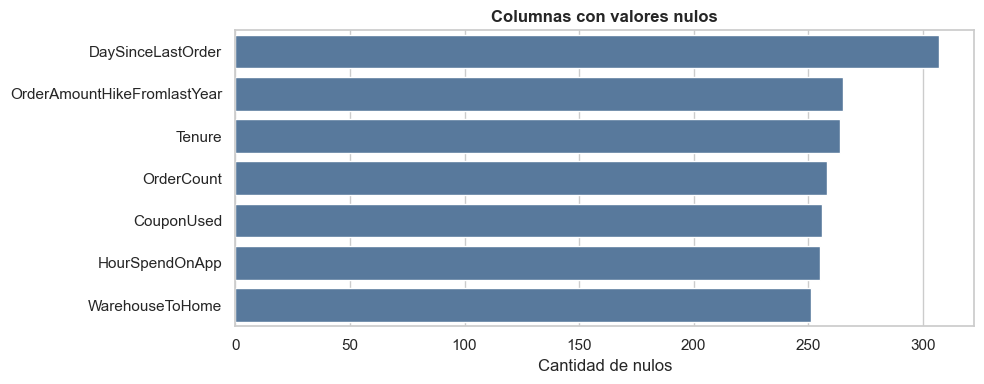

In [3]:
missing = dtype_summary[dtype_summary["nulos"] > 0].sort_values("nulos", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=missing, x="nulos", y="variable", ax=ax, color="#4C78A8")
ax.set_title("Columnas con valores nulos")
ax.set_xlabel("Cantidad de nulos")
ax.set_ylabel("")
plt.tight_layout()

missing

## 2.1. Patron de nulos y criterio para modelado

Antes de avanzar con el analisis conviene responder una pregunta practica: los nulos estan concentrados en los mismos clientes o aparecen dispersos? Esto define si conviene borrar filas, imputar valores o crear senales adicionales.

In [4]:
missing_cols = df_raw.columns[df_raw.isna().any()].tolist()
row_missing = df_raw[missing_cols].isna().sum(axis=1)

missing_pattern_summary = pd.DataFrame({
    "cantidad_de_nulos_en_la_fila": row_missing.value_counts().sort_index().index,
    "filas": row_missing.value_counts().sort_index().values,
})
missing_pattern_summary["%_filas"] = (missing_pattern_summary["filas"] / len(df_raw) * 100).round(2)

print(f"Filas con al menos un nulo: {(row_missing > 0).sum():,} ({(row_missing > 0).mean() * 100:.2f}%)")
print(f"Maximo de nulos en una misma fila: {row_missing.max()}")
missing_pattern_summary

Filas con al menos un nulo: 1,856 (32.97%)
Maximo de nulos en una misma fila: 1


,cantidad_de_nulos_en_la_fila,filas,%_filas
0,0,3774,67.030
1,1,1856,32.970


,Tenure,WarehouseToHome,HourSpendOnApp,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder
Tenure,264,0,0,0,0,0,0
WarehouseToHome,0,251,0,0,0,0,0
HourSpendOnApp,0,0,255,0,0,0,0
OrderAmountHikeFromlastYear,0,0,0,265,0,0,0
CouponUsed,0,0,0,0,256,0,0
OrderCount,0,0,0,0,0,258,0
DaySinceLastOrder,0,0,0,0,0,0,307


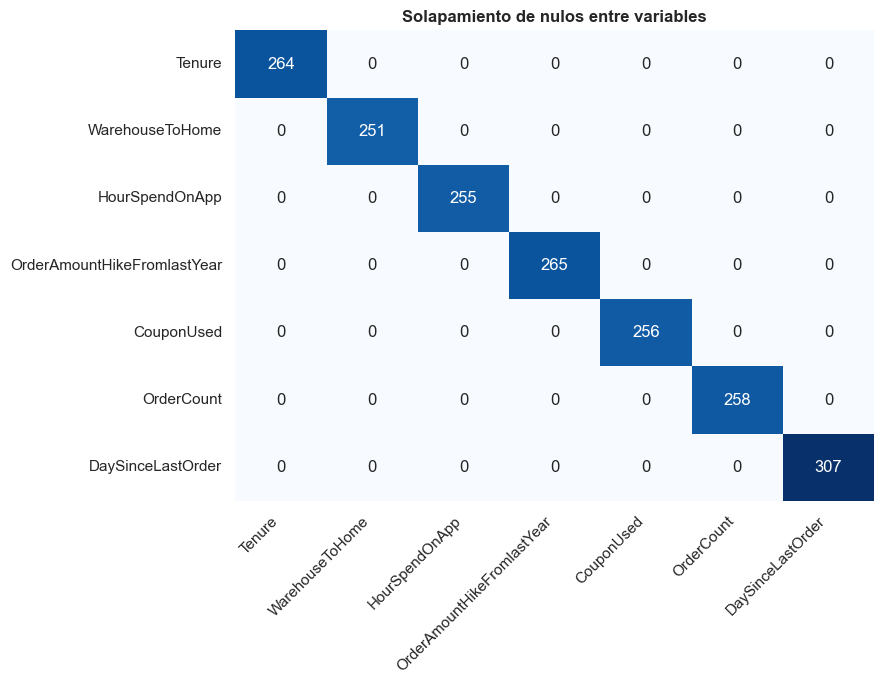

In [5]:
missing_overlap = df_raw[missing_cols].isna().astype(int).T.dot(df_raw[missing_cols].isna().astype(int))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(missing_overlap, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Solapamiento de nulos entre variables")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

missing_overlap

**Lectura:** los nulos no se superponen: cada cliente con datos faltantes tiene faltante una sola variable. Borrar todas esas filas eliminaria casi un tercio de la base y podria sesgar el problema. Para modelado, la estrategia razonable es imputar dentro de un pipeline entrenado solo con train y evaluar si conviene agregar indicadores de nulo.

In [6]:
missing_signal = []
for col in missing_cols:
    tmp = df_raw.assign(is_missing=df_raw[col].isna()).groupby("is_missing")["Churn"].agg(clientes="count", tasa_churn="mean")
    missing_signal.append({
        "variable": col,
        "nulos": int(df_raw[col].isna().sum()),
        "%_nulos": round(df_raw[col].isna().mean() * 100, 2),
        "churn_si_falta": round(tmp.loc[True, "tasa_churn"] * 100, 2),
        "churn_si_no_falta": round(tmp.loc[False, "tasa_churn"] * 100, 2),
        "diferencia_pp": round((tmp.loc[True, "tasa_churn"] - tmp.loc[False, "tasa_churn"]) * 100, 2),
    })

missing_signal = pd.DataFrame(missing_signal).sort_values("diferencia_pp", ascending=False)
missing_signal

,variable,nulos,%_nulos,churn_si_falta,churn_si_no_falta,diferencia_pp
1,WarehouseToHome,251,4.460,33.470,16.060,17.400
0,Tenure,264,4.690,30.680,16.160,14.520
2,HourSpendOnApp,255,4.530,22.750,16.560,6.190
6,DaySinceLastOrder,307,5.450,17.590,16.800,0.790
5,OrderCount,258,4.580,6.980,17.310,-10.340
3,OrderAmountHikeFromlastYear,265,4.710,5.280,17.410,-12.130
4,CouponUsed,256,4.550,3.120,17.490,-14.370


In [7]:
missing_treatment_plan = pd.DataFrame([
    {
        "variable": "Tenure",
        "que_mide": "Meses como cliente",
        "senal_del_nulo": "El faltante tiene churn mas alto que el promedio.",
        "tratamiento_modelado": "Comparar KNN vs regresion iterativa con variables estandarizadas y usar el menor MAE.",
    },
    {
        "variable": "WarehouseToHome",
        "que_mide": "Distancia o tiempo desde deposito al hogar",
        "senal_del_nulo": "El faltante tiene churn mas alto, pero no podemos inferir si vive cerca o lejos.",
        "tratamiento_modelado": "Imputar por mediana como recurso simple y defendible.",
    },
    {
        "variable": "HourSpendOnApp",
        "que_mide": "Horas de uso de la app",
        "senal_del_nulo": "El faltante tiene algo mas de churn.",
        "tratamiento_modelado": "Comparar KNN vs regresion iterativa con variables estandarizadas y usar el menor MAE.",
    },
    {
        "variable": "OrderAmountHikeFromlastYear",
        "que_mide": "Aumento del monto de orden vs ano anterior",
        "senal_del_nulo": "El faltante tiene churn menor; puede representar clientes sin historial comparable.",
        "tratamiento_modelado": "Comparar KNN vs regresion iterativa con variables estandarizadas y usar el menor MAE.",
    },
    {
        "variable": "CouponUsed",
        "que_mide": "Cupones usados",
        "senal_del_nulo": "El faltante no debe interpretarse como cero, porque ya existen valores 0 reales.",
        "tratamiento_modelado": "Imputar por mediana como criterio simple y defendible.",
    },
    {
        "variable": "OrderCount",
        "que_mide": "Cantidad de ordenes",
        "senal_del_nulo": "El faltante tiene churn menor.",
        "tratamiento_modelado": "Comparar KNN vs regresion iterativa con variables estandarizadas y usar el menor MAE.",
    },
    {
        "variable": "DaySinceLastOrder",
        "que_mide": "Dias desde la ultima orden",
        "senal_del_nulo": "El faltante tiene churn parecido al promedio.",
        "tratamiento_modelado": "Comparar KNN vs regresion iterativa con variables estandarizadas y usar el menor MAE.",
    },
])

missing_treatment_plan

,variable,que_mide,senal_del_nulo,tratamiento_modelado
0,Tenure,Meses como cliente,El faltante tiene churn mas alto que el promedio.,Comparar KNN vs regresion iterativa con variab...
1,WarehouseToHome,Distancia o tiempo desde deposito al hogar,"El faltante tiene churn mas alto, pero no pode...",Imputar por mediana como recurso simple y defe...
2,HourSpendOnApp,Horas de uso de la app,El faltante tiene algo mas de churn.,Comparar KNN vs regresion iterativa con variab...
3,OrderAmountHikeFromlastYear,Aumento del monto de orden vs ano anterior,El faltante tiene churn menor; puede represent...,Comparar KNN vs regresion iterativa con variab...
4,CouponUsed,Cupones usados,"El faltante no debe interpretarse como cero, p...",Imputar por mediana como criterio simple y def...
5,OrderCount,Cantidad de ordenes,El faltante tiene churn menor.,Comparar KNN vs regresion iterativa con variab...
6,DaySinceLastOrder,Dias desde la ultima orden,El faltante tiene churn parecido al promedio.,Comparar KNN vs regresion iterativa con variab...


**Decision para llevar a modelado:** no eliminar filas con nulos. `WarehouseToHome` y `CouponUsed` se imputan por mediana porque no podemos defender una distancia o cantidad de cupones inventada como dato real. Para el resto de variables numericas con nulos, se comparan KNN y regresion iterativa con estandarizacion previa, y se usa el metodo con menor error simulado por variable.

In [8]:
categorical_cols = df_raw.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    print(f"\n{col}")
    print(df_raw[col].value_counts(dropna=False))


PreferredLoginDevice
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

PreferredPaymentMode
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Gender
Gender
Male      3384
Female    2246
Name: count, dtype: int64

PreferedOrderCat
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


**Inconsistencias detectadas:**

- `PreferredLoginDevice`: aparecen `Phone` y `Mobile Phone`, que probablemente representan lo mismo.
- `PreferredPaymentMode`: aparecen `COD` y `Cash on Delivery`; tambien `CC` y `Credit Card`.
- `PreferedOrderCat`: aparecen `Mobile` y `Mobile Phone`, probablemente categorias equivalentes o muy cercanas.

Para los graficos de negocio se normalizan estas etiquetas en una copia en memoria, sin editar el CSV original.

In [9]:
df = df_raw.copy()

# Normalizacion de categorias para evitar duplicados semanticos en tablas y graficos.
df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({
    "Phone": "Mobile Phone",
})
df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace({
    "COD": "Cash on Delivery",
    "CC": "Credit Card",
})
df["PreferedOrderCat"] = df["PreferedOrderCat"].replace({
    "Mobile": "Mobile Phone",
})

# Criterio acordado: estas dos variables se imputan por mediana, no por KNN.
median_imputations = {
    "WarehouseToHome": df["WarehouseToHome"].median(),
    "CouponUsed": df["CouponUsed"].median(),
}
for col, value in median_imputations.items():
    df[col] = df[col].fillna(value)

clean_categories = {
    col: df[col].value_counts(dropna=False).rename("count").to_frame()
    for col in categorical_cols
}

print("Medianas usadas para imputar:")
print(median_imputations)
clean_categories["PreferredPaymentMode"]

Medianas usadas para imputar:
{'WarehouseToHome': np.float64(14.0), 'CouponUsed': np.float64(1.0)}


,count
PreferredPaymentMode,
Debit Card,2314
Credit Card,1774
E wallet,614
Cash on Delivery,514
UPI,414


## 2.2. Comparacion KNN vs regresion para imputar el resto

Para las variables restantes con nulos no usamos mediana automaticamente. Comparamos dos metodos multivariados:

- **KNNImputer:** estima usando clientes parecidos.
- **IterativeImputer:** estima por regresion iterativa usando las demas variables.

Antes de aplicar cualquiera de los dos, se estandarizan las variables numericas con `StandardScaler`. Esto es importante porque KNN mide distancias y, sin escala comun, variables grandes como `CashbackAmount` dominarian el calculo.

In [10]:
imputation_features = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CityTier",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "Complain",
    "CashbackAmount",
]

model_imputation_cols = [
    "Tenure",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "OrderCount",
    "DaySinceLastOrder",
]

X_impute_base = df[imputation_features].copy()


def fit_scaled_imputer(data, imputer):
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(data),
        columns=data.columns,
        index=data.index,
    )
    X_imputed_scaled = imputer.fit_transform(X_scaled)
    X_imputed = pd.DataFrame(
        scaler.inverse_transform(X_imputed_scaled),
        columns=data.columns,
        index=data.index,
    )
    return X_imputed


def evaluate_scaled_imputer_for_column(data, target_col, imputer, random_state=42, mask_fraction=0.2):
    observed_idx = data.index[data[target_col].notna()].to_numpy()
    rng = np.random.default_rng(random_state)
    mask_size = max(1, int(len(observed_idx) * mask_fraction))
    masked_idx = rng.choice(observed_idx, size=mask_size, replace=False)

    X_masked = data.copy()
    y_true = X_masked.loc[masked_idx, target_col].copy()
    X_masked.loc[masked_idx, target_col] = np.nan

    X_imputed = fit_scaled_imputer(X_masked, imputer)
    y_pred = X_imputed.loc[masked_idx, target_col]
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    return mae, rmse, len(masked_idx)


imputer_specs = {
    "knn_k5": KNNImputer(n_neighbors=5, weights="distance"),
    "iterative_regression": IterativeImputer(
        random_state=42,
        max_iter=20,
        initial_strategy="median",
        sample_posterior=False,
    ),
}

imputation_results = []
for target_col in model_imputation_cols:
    for method, imputer in imputer_specs.items():
        mae, rmse, n_eval = evaluate_scaled_imputer_for_column(
            X_impute_base,
            target_col=target_col,
            imputer=imputer,
            random_state=42,
            mask_fraction=0.2,
        )
        imputation_results.append({
            "variable": target_col,
            "metodo": method,
            "n_validacion": n_eval,
            "MAE": mae,
            "RMSE": rmse,
        })

imputation_results = pd.DataFrame(imputation_results)
best_imputer_by_variable = imputation_results.loc[
    imputation_results.groupby("variable")["MAE"].idxmin()
].sort_values("variable")

imputation_results.sort_values(["variable", "MAE"])

,variable,metodo,n_validacion,MAE,RMSE
8,DaySinceLastOrder,knn_k5,1064,1.356,2.090
9,DaySinceLastOrder,iterative_regression,1064,2.313,2.955
2,HourSpendOnApp,knn_k5,1075,0.366,0.530
3,HourSpendOnApp,iterative_regression,1075,0.544,0.671
4,OrderAmountHikeFromlastYear,knn_k5,1073,1.942,2.830
5,OrderAmountHikeFromlastYear,iterative_regression,1073,2.947,3.548
6,OrderCount,knn_k5,1074,0.784,1.700
7,OrderCount,iterative_regression,1074,1.255,1.956
0,Tenure,knn_k5,1073,3.675,5.642
1,Tenure,iterative_regression,1073,5.867,7.470


,variable,metodo,n_validacion,MAE,RMSE
8,DaySinceLastOrder,knn_k5,1064,1.356,2.090
2,HourSpendOnApp,knn_k5,1075,0.366,0.530
4,OrderAmountHikeFromlastYear,knn_k5,1073,1.942,2.830
6,OrderCount,knn_k5,1074,0.784,1.700
0,Tenure,knn_k5,1073,3.675,5.642


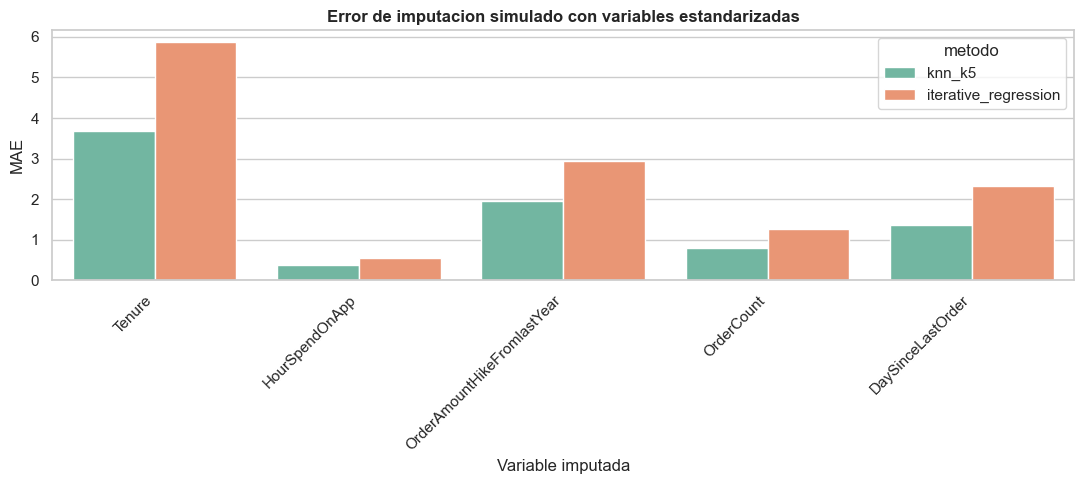

In [11]:
knn_imputed = fit_scaled_imputer(
    X_impute_base,
    KNNImputer(n_neighbors=5, weights="distance"),
)
iterative_imputed = fit_scaled_imputer(
    X_impute_base,
    IterativeImputer(
        random_state=42,
        max_iter=20,
        initial_strategy="median",
        sample_posterior=False,
    ),
)

imputed_sources = {
    "knn_k5": knn_imputed,
    "iterative_regression": iterative_imputed,
}

for _, row in best_imputer_by_variable.iterrows():
    col = row["variable"]
    method = row["metodo"]
    missing_mask = df[col].isna()
    df.loc[missing_mask, col] = imputed_sources[method].loc[missing_mask, col]

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=imputation_results, x="variable", y="MAE", hue="metodo", ax=ax)
ax.set_title("Error de imputacion simulado con variables estandarizadas")
ax.set_xlabel("Variable imputada")
ax.set_ylabel("MAE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

best_imputer_by_variable

**Decision de imputacion:** `WarehouseToHome` y `CouponUsed` quedan por mediana. Para las demas variables se usa el metodo ganador por MAE en la validacion simulada, despues de estandarizar. Esta imputacion es un recurso tecnico para no perder filas; no se interpreta como verdad observada.

In [12]:
numeric_cols = [c for c in df.select_dtypes(exclude="object").columns if c != "CustomerID"]
numeric_summary = df[numeric_cols].describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
Churn,"5,630.000",0.168,0.374,0.000,0.000,0.000,0.000,1.000
Tenure,"5,630.000",9.992,8.456,-0.000,2.000,8.000,15.000,61.000
CityTier,"5,630.000",1.655,0.915,1.000,1.000,1.000,3.000,3.000
WarehouseToHome,"5,630.000",15.567,8.346,5.000,9.000,14.000,20.000,127.000
HourSpendOnApp,"5,630.000",2.921,0.712,0.000,2.000,3.000,3.000,5.000
NumberOfDeviceRegistered,"5,630.000",3.689,1.024,1.000,3.000,4.000,4.000,6.000
SatisfactionScore,"5,630.000",3.067,1.380,1.000,2.000,3.000,4.000,5.000
NumberOfAddress,"5,630.000",4.214,2.584,1.000,2.000,3.000,6.000,22.000
Complain,"5,630.000",0.285,0.451,0.000,0.000,0.000,1.000,1.000
OrderAmountHikeFromlastYear,"5,630.000",15.719,3.618,11.000,13.000,15.000,18.000,26.000


Filas para EDA: 5,623 de 5,630


,criterio,filas_excluidas
0,WarehouseToHome extremo IQR,2
1,Tenure extremos IQR,4
2,DaySinceLastOrder maximo,1
3,Total unico excluido,7


,variable,limite_inferior,limite_superior,outliers_IQR,%_filas,min,max
4,OrderCount,-2.000,6.000,766,13.610,1.000,16.000
5,CouponUsed,-0.500,3.500,629,11.170,0.000,16.000
2,CashbackAmount,71.000,271.000,447,7.940,0.000,325.000
1,DaySinceLastOrder,-5.500,14.500,64,1.140,0.000,46.000
3,Tenure,-17.500,34.500,4,0.070,-0.000,61.000
0,WarehouseToHome,-7.500,36.500,2,0.040,5.000,127.000


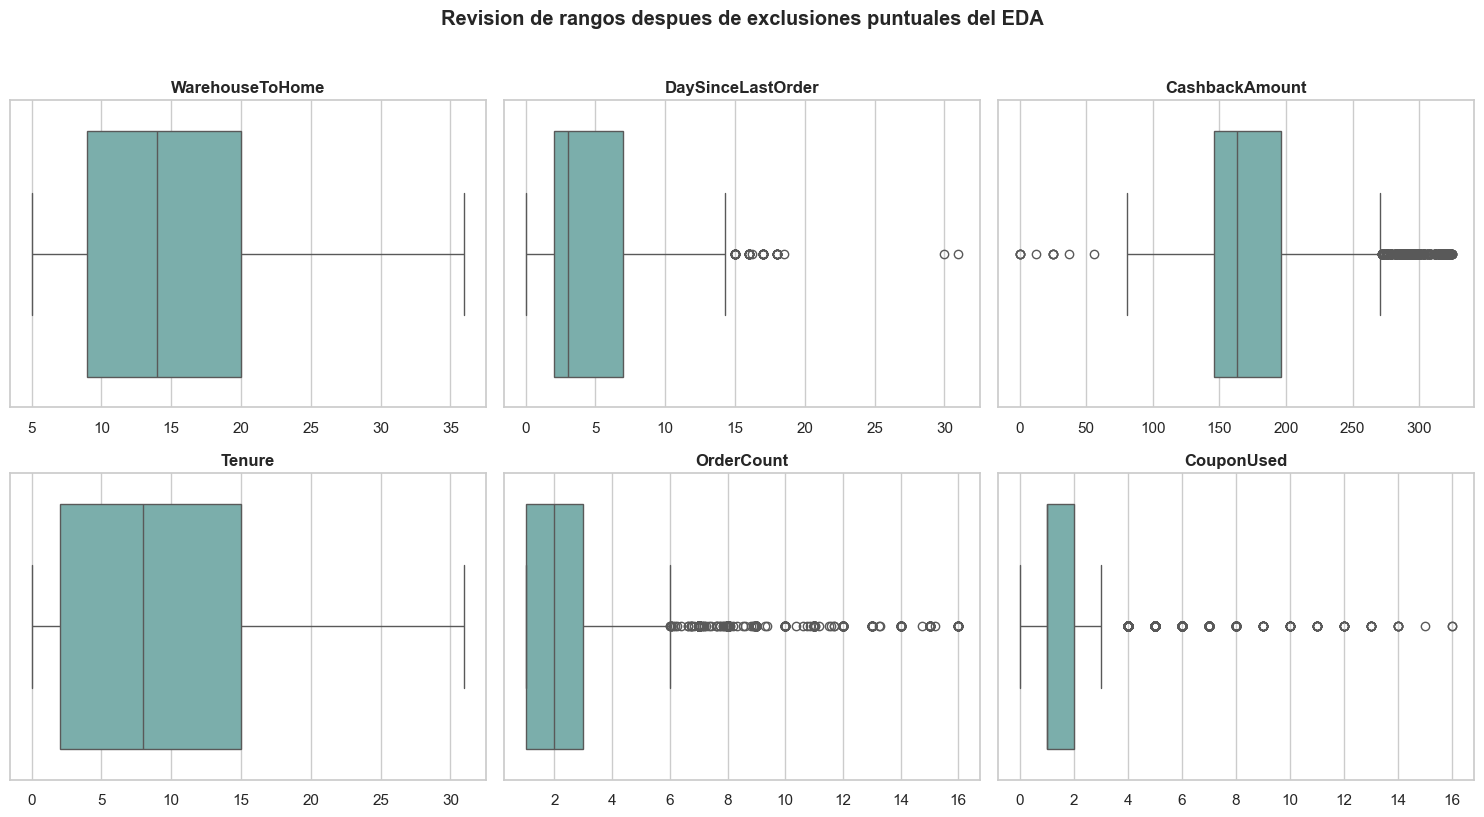

In [13]:
outlier_focus = ["WarehouseToHome", "DaySinceLastOrder", "CashbackAmount", "Tenure", "OrderCount", "CouponUsed"]

outlier_bounds = {}
outlier_rows = []
for col in outlier_focus:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = df[col].notna() & ((df[col] < lower) | (df[col] > upper))
    outlier_bounds[col] = (lower, upper)
    outlier_rows.append({
        "variable": col,
        "limite_inferior": lower,
        "limite_superior": upper,
        "outliers_IQR": int(mask.sum()),
        "%_filas": round(mask.mean() * 100, 2),
        "min": df[col].min(),
        "max": df[col].max(),
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outliers_IQR", ascending=False)

warehouse_lower, warehouse_upper = outlier_bounds["WarehouseToHome"]
warehouse_extreme_mask = df["WarehouseToHome"].notna() & ~df["WarehouseToHome"].between(warehouse_lower, warehouse_upper)

tenure_lower, tenure_upper = outlier_bounds["Tenure"]
tenure_extreme_mask = df["Tenure"].notna() & ~df["Tenure"].between(tenure_lower, tenure_upper)

day_since_last_order_extreme_mask = df["DaySinceLastOrder"] == df["DaySinceLastOrder"].max()

eda_exclusion_mask = warehouse_extreme_mask | tenure_extreme_mask | day_since_last_order_extreme_mask
df_eda = df.loc[~eda_exclusion_mask].copy()

exclusion_summary = pd.DataFrame([
    {"criterio": "WarehouseToHome extremo IQR", "filas_excluidas": int(warehouse_extreme_mask.sum())},
    {"criterio": "Tenure extremos IQR", "filas_excluidas": int(tenure_extreme_mask.sum())},
    {"criterio": "DaySinceLastOrder maximo", "filas_excluidas": int(day_since_last_order_extreme_mask.sum())},
    {"criterio": "Total unico excluido", "filas_excluidas": int(eda_exclusion_mask.sum())},
])

print(f"Filas para EDA: {len(df_eda):,} de {len(df):,}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), outlier_focus):    
    sns.boxplot(data=df_eda, x=col, ax=ax, color="#72B7B2")
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Revision de rangos despues de exclusiones puntuales del EDA", y=1.02, fontweight="bold")
plt.tight_layout()

display(exclusion_summary)
outlier_summary

**Lectura de outliers:** no todo valor grande es necesariamente un error. Variables como `OrderCount`, `CouponUsed` o `CashbackAmount` pueden tener clientes naturalmente grandes. Para este EDA solo se excluyen filas puntuales que rompen la lectura: 2 casos extremos de `WarehouseToHome`, los 4 extremos de `Tenure` y el valor maximo de `DaySinceLastOrder`. El CSV original no se modifica.

In [14]:
def analysis_data_for(variable):
    """Base de EDA con exclusiones puntuales de outliers no defendibles."""
    return df_eda

print(f"Churn base completa: {df['Churn'].mean() * 100:.2f}%")
print(f"Churn base EDA con exclusiones puntuales: {df_eda['Churn'].mean() * 100:.2f}%")

Churn base completa: 16.84%
Churn base EDA con exclusiones puntuales: 16.84%


In [15]:
def plot_100pct_stacked(data, group_col, ax, title, max_regular=None, order=None, xlabel=None):
    plot_df = data[[group_col, "Churn"]].dropna().copy()
    if max_regular is not None:
        numeric_group = plot_df[group_col].round().astype(int)
        plot_df[group_col] = np.where(numeric_group > max_regular, f">{max_regular}", numeric_group.astype(str))
        if order is None:
            order = [str(i) for i in range(0, max_regular + 1) if str(i) in set(plot_df[group_col])] + [f">{max_regular}"]
    elif order is None:
        order = sorted(plot_df[group_col].unique())

    prop = pd.crosstab(plot_df[group_col], plot_df["Churn"], normalize="index").rename(columns=CHURN_LABELS)
    prop = prop.reindex(columns=["No churn", "Churn"], fill_value=0)
    prop = prop.loc[[x for x in order if x in prop.index]]

    x = np.arange(len(prop))
    bottom = np.zeros(len(prop))
    for label, color in [("No churn", CHURN_COLORS[0]), ("Churn", CHURN_COLORS[1])]:
        values = prop[label].values
        ax.bar(x, values, bottom=bottom, color=color, edgecolor="white", width=0.78, label=label)
        bottom += values

    churn_values = prop["Churn"].values
    for i, value in enumerate(churn_values):
        ax.text(i, 1.015, f"{value * 100:.1f}%", ha="center", va="bottom", fontsize=8, color=CHURN_COLORS[1], weight="bold")

    ax.set_title(title)
    ax.set_xlabel(xlabel or group_col)
    ax.set_ylabel("Proporcion")
    ax.set_ylim(0, 1.08)
    ax.set_xticks(x)
    ax.set_xticklabels(prop.index, rotation=45 if len(prop) > 6 else 0)
    ax.legend(frameon=False, loc="lower left")
    return prop


def plot_churn_rate_lollipop(data, group_col, ax, title, order=None, min_n=20, xlabel=None):
    plot_df = data[[group_col, "Churn"]].dropna().copy()
    summary = plot_df.groupby(group_col)["Churn"].agg(clientes="count", tasa_churn="mean").reset_index()
    summary = summary[summary["clientes"] >= min_n].copy()
    if order is not None:
        summary[group_col] = pd.Categorical(summary[group_col], categories=order, ordered=True)
        summary = summary.sort_values(group_col)
    else:
        summary = summary.sort_values(group_col)

    x = np.arange(len(summary))
    y = summary["tasa_churn"] * 100
    ax.vlines(x, 0, y, color="#D9D9D9", linewidth=2)
    ax.scatter(x, y, color=CHURN_COLORS[1], s=70, zorder=3)
    baseline = data["Churn"].mean() * 100
    ax.axhline(baseline, color="#666666", linestyle="--", linewidth=1, label=f"Base {baseline:.1f}%")
    for i, (rate, n) in enumerate(zip(y, summary["clientes"])):
        ax.text(i, rate + 0.8, f"{rate:.1f}%\nn={n}", ha="center", va="bottom", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xlabel or group_col)
    ax.set_ylabel("Tasa de churn (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(summary[group_col].astype(str), rotation=45 if len(summary) > 6 else 0)
    ax.set_ylim(0, max(y.max() * 1.25, baseline * 1.5))
    ax.legend(frameon=False)
    return summary

## 3. Churn general

Antes de segmentar, medimos la proporcion base. Esto es clave porque el dataset esta desbalanceado.

/var/folders/6z/2nkwfpvj5vdbpmc404rhvrsh0000gn/T/ipykernel_74370/518609980.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_summary, x="estado", y="clientes", ax=ax, palette=["#59A14F", "#E15759"])


,Churn,clientes,%,estado
0,0,4682,83.160,Sigue activo
1,1,948,16.840,Se fue


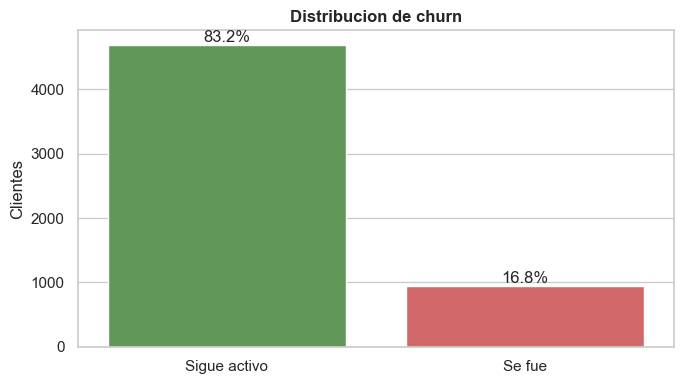

In [16]:
churn_counts = df["Churn"].value_counts().sort_index()
churn_summary = pd.DataFrame({
    "Churn": churn_counts.index,
    "clientes": churn_counts.values,
    "%": (churn_counts.values / len(df) * 100).round(2),
})
churn_summary["estado"] = churn_summary["Churn"].map({0: "Sigue activo", 1: "Se fue"})

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=churn_summary, x="estado", y="clientes", ax=ax, palette=["#59A14F", "#E15759"])
ax.set_title("Distribucion de churn")
ax.set_xlabel("")
ax.set_ylabel("Clientes")
for p, pct in zip(ax.patches, churn_summary["%"]):
    ax.annotate(f"{pct:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
plt.tight_layout()

churn_summary

**Interpretacion:** cerca del 17% de la base churnea. Si un modelo futuro dijera siempre "nadie se va", tendria alrededor de 83% de accuracy, pero seria inutil para el gerente comercial porque no detectaria a ningun cliente en riesgo. Por eso mas adelante habra que mirar metricas como recall y precision, no solo accuracy.

## 4. Funciones auxiliares para hipotesis

Cada hipotesis se valida con un grafico y una prueba estadistica simple. Las pruebas no reemplazan la interpretacion de negocio: ayudan a evitar conclusiones basadas solo en intuicion visual.

Ademas del p-valor, se reporta tama?o de efecto. Esto importa porque, con muchas filas, una diferencia puede ser estadisticamente significativa pero poco relevante para una decision comercial.

**Mejora ds-stats:** ademas del p-valor, reportamos tama?o de efecto. Con 5.630 filas, un p-valor puede ser significativo aunque el impacto sea chico. Para variables numericas usamos rank-biserial; para categoricas usamos Cram?r's V.

In [17]:
def numeric_hypothesis_summary(data, variable):
    analysis_data = analysis_data_for(variable)
    active = analysis_data.loc[analysis_data["Churn"] == 0, variable].dropna()
    churned = analysis_data.loc[analysis_data["Churn"] == 1, variable].dropna()
    stat, p_value = stats.mannwhitneyu(active, churned, alternative="two-sided")
    rank_biserial = (2 * stat / (len(active) * len(churned))) - 1
    return pd.DataFrame({
        "grupo": ["Sigue activo", "Se fue"],
        "n": [len(active), len(churned)],
        "media": [active.mean(), churned.mean()],
        "mediana": [active.median(), churned.median()],
        "p_value_mann_whitney": [p_value, p_value],
        "rank_biserial": [rank_biserial, rank_biserial],
        "interpretacion_efecto": [interpret_rank_biserial(rank_biserial), interpret_rank_biserial(rank_biserial)],
    })


def categorical_churn_table(data, variable):
    table = data.groupby(variable, dropna=False)["Churn"].agg(clientes="count", tasa_churn="mean")
    table["tasa_churn_%"] = (table["tasa_churn"] * 100).round(2)
    return table.sort_values("tasa_churn", ascending=False)


def cramers_v(contingency):
    chi2, _, _, _ = stats.chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    if n == 0:
        return np.nan
    rows, cols = contingency.shape
    denominator = n * (min(rows - 1, cols - 1))
    return np.sqrt(chi2 / denominator) if denominator else np.nan


def interpret_cramers_v(value):
    if pd.isna(value):
        return "sin efecto interpretable"
    if value < 0.10:
        return "efecto bajo"
    if value < 0.30:
        return "efecto medio"
    return "efecto alto"


def interpret_rank_biserial(value):
    abs_value = abs(value)
    if abs_value < 0.10:
        return "efecto bajo"
    if abs_value < 0.30:
        return "efecto medio"
    return "efecto alto"


def chi_square_test(data, variable):
    contingency = pd.crosstab(data[variable], data["Churn"])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    effect = cramers_v(contingency)
    return pd.DataFrame({
        "variable": [variable],
        "chi2": [chi2],
        "p_value": [p_value],
        "dof": [dof],
        "cramers_v": [effect],
        "interpretacion_efecto": [interpret_cramers_v(effect)],
    })

## 5. Hipotesis de negocio

### H1: Los clientes nuevos tienen mayor riesgo de churn

**Logica de negocio:** si un cliente lleva poco tiempo con la empresa, todavia no desarrollo habito, confianza ni switching cost. Es mas facil que pruebe otro e-commerce.

,grupo,n,media,mediana,p_value_mann_whitney,rank_biserial,interpretacion_efecto
0,Sigue activo,4676,11.248,10.000,0.000,0.608,efecto alto
1,Se fue,947,3.571,1.000,0.000,0.608,efecto alto


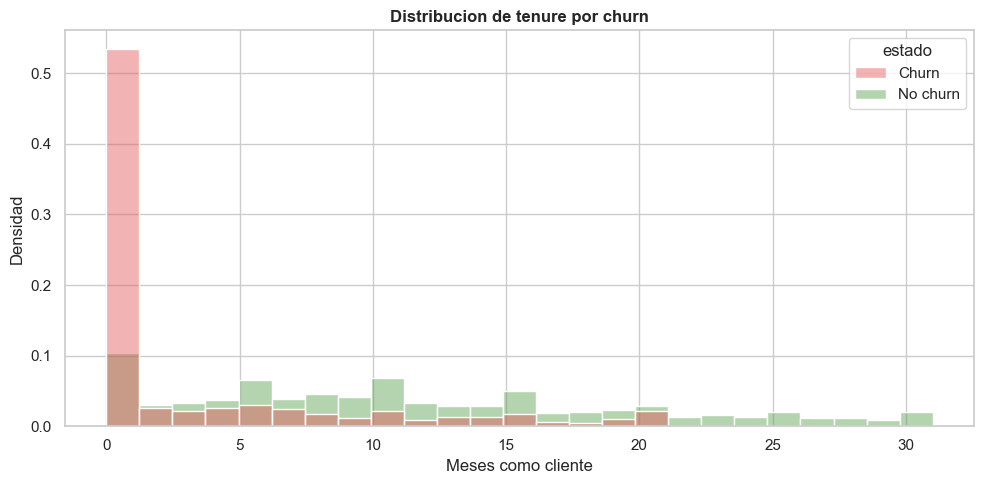

In [18]:
tenure_df = analysis_data_for("Tenure").copy()
tenure_df["estado"] = tenure_df["Churn"].map(CHURN_LABELS)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=tenure_df,
    x="Tenure",
    hue="estado",
    bins=25,
    stat="density",
    common_norm=False,
    palette={"No churn": CHURN_COLORS[0], "Churn": CHURN_COLORS[1]},
    alpha=0.45,
    ax=ax,
)
ax.set_title("Distribucion de tenure por churn")
ax.set_xlabel("Meses como cliente")
ax.set_ylabel("Densidad")
plt.tight_layout()

numeric_hypothesis_summary(df, "Tenure")

**Interpretacion:** los clientes que se fueron tienen una antiguedad promedio mucho menor. Esto sugiere que la retencion temprana es critica: onboarding, beneficios iniciales y seguimiento de los primeros meses deberian ser prioridad.

### H2: Los clientes que hicieron reclamos churnean mas

**Logica de negocio:** un reclamo puede ser una senal de mala experiencia. Pero hay que tener cuidado: si el reclamo se registro despues de la baja, usarlo como predictor seria leakage temporal.

,clientes,tasa_churn,tasa_churn_%
Complain,,,
1,1602,0.317,31.710
0,4021,0.109,10.920


,variable,chi2,p_value,dof,cramers_v,interpretacion_efecto
0,Complain,352.157,0.000,1,0.250,efecto medio


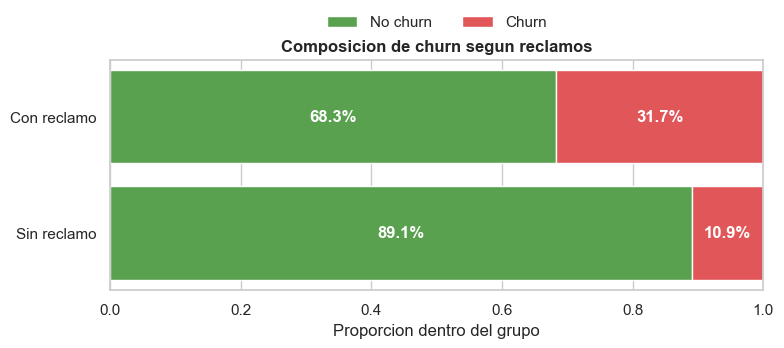

In [19]:
complain_table = categorical_churn_table(df_eda, "Complain")

complain_prop = pd.crosstab(df_eda["Complain"], df_eda["Churn"], normalize="index")
complain_prop = complain_prop.rename(index={0: "Sin reclamo", 1: "Con reclamo"}, columns=CHURN_LABELS)
complain_prop = complain_prop.loc[["Sin reclamo", "Con reclamo"]]

fig, ax = plt.subplots(figsize=(8, 3.8))
left = np.zeros(len(complain_prop))
y_pos = np.arange(len(complain_prop))
for label, color in [("No churn", CHURN_COLORS[0]), ("Churn", CHURN_COLORS[1])]:
    values = complain_prop[label].values
    ax.barh(y_pos, values, left=left, color=color, edgecolor="white", label=label)
    for i, value in enumerate(values):
        if value > 0.08:
            ax.text(left[i] + value / 2, i, f"{value * 100:.1f}%", ha="center", va="center", color="white", weight="bold")
    left += values
ax.set_yticks(y_pos)
ax.set_yticklabels(complain_prop.index)
ax.set_xlim(0, 1)
ax.set_xlabel("Proporcion dentro del grupo")
ax.set_title("Composicion de churn segun reclamos")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.25), ncol=2, frameon=False)
plt.tight_layout()

display(complain_table)
chi_square_test(df_eda, "Complain")

**Interpretacion:** reclamar esta asociado a una tasa de churn mas alta. Como accion de negocio, los reclamos deberian disparar un flujo de recuperacion de experiencia. Como decision tecnica futura, hay que confirmar la temporalidad de `Complain` antes de usarla en un modelo.

### H3: Los clientes con mas dias desde la ultima orden estan mas cerca de irse

**Logica de negocio:** la inactividad suele anticipar abandono. Si un cliente no compra hace tiempo, puede estar migrando a otro canal o competidor.

,grupo,n,media,mediana,p_value_mann_whitney,rank_biserial,interpretacion_efecto
0,Sigue activo,4676,4.858,4.000,0.000,0.270,efecto medio
1,Se fue,947,3.371,2.000,0.000,0.270,efecto medio


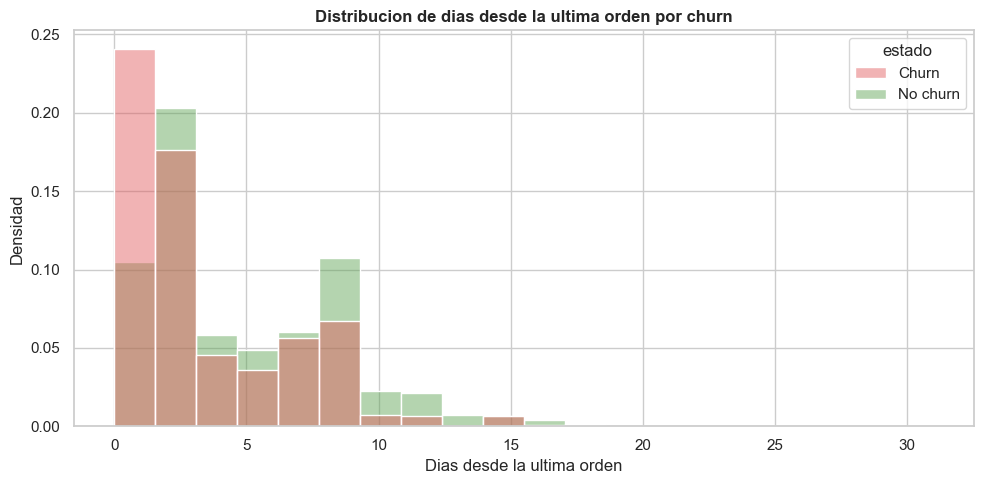

In [20]:
plot_df = analysis_data_for("DaySinceLastOrder").copy()
plot_df["estado"] = plot_df["Churn"].map(CHURN_LABELS)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=plot_df,
    x="DaySinceLastOrder",
    hue="estado",
    bins=20,
    stat="density",
    common_norm=False,
    palette={"No churn": CHURN_COLORS[0], "Churn": CHURN_COLORS[1]},
    alpha=0.45,
    ax=ax,
)
ax.set_title("Distribucion de dias desde la ultima orden por churn")
ax.set_xlabel("Dias desde la ultima orden")
ax.set_ylabel("Densidad")
plt.tight_layout()

numeric_hypothesis_summary(df, "DaySinceLastOrder")

**Interpretacion:** en este dataset, los clientes que se fueron muestran menos dias desde la ultima orden en promedio. Esto contradice la intuicion inicial y puede indicar que la definicion de churn o la ventana temporal del dato no es obvia. Se recomienda documentar esta variable como sensible a temporalidad antes de modelar.

### H4: Menor cashback o menor actividad transaccional se asocia a mayor churn

**Logica de negocio:** clientes con menor relacion economica con la plataforma pueden tener menos incentivos para quedarse. El cashback podria funcionar como beneficio de fidelizacion o como reflejo de mayor actividad.

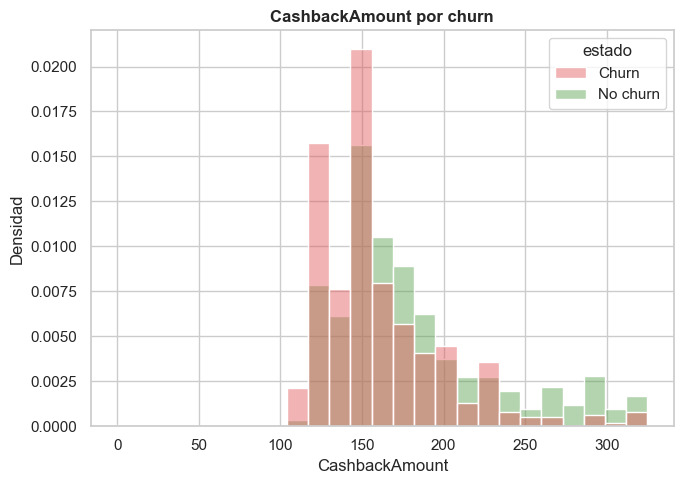

In [21]:


fig, ax = plt.subplots(figsize=(7, 5))

cashback_df = analysis_data_for("CashbackAmount").copy()
cashback_df["estado"] = cashback_df["Churn"].map(CHURN_LABELS)

sns.histplot(
    data=cashback_df,
    x="CashbackAmount",
    hue="estado",
    bins=25,
    stat="density",
    common_norm=False,
    palette={"No churn": CHURN_COLORS[0], "Churn": CHURN_COLORS[1]},
    alpha=0.45,
    ax=ax,
)

ax.set_title("CashbackAmount por churn")
ax.set_xlabel("CashbackAmount")
ax.set_ylabel("Densidad")

plt.tight_layout()
plt.show()


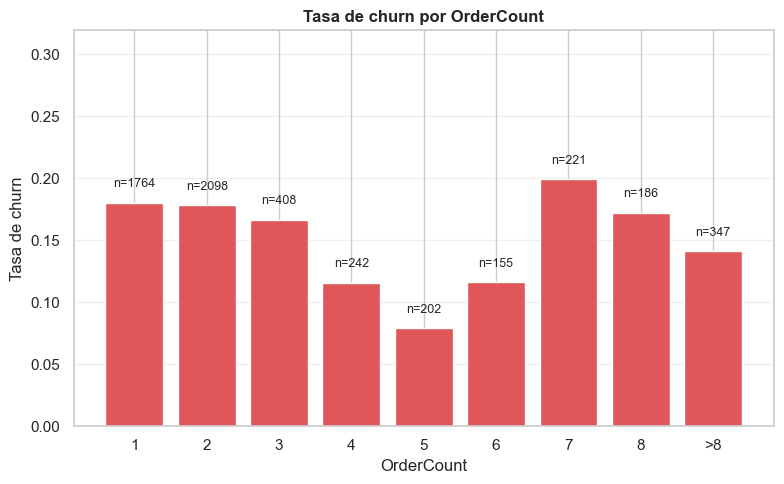

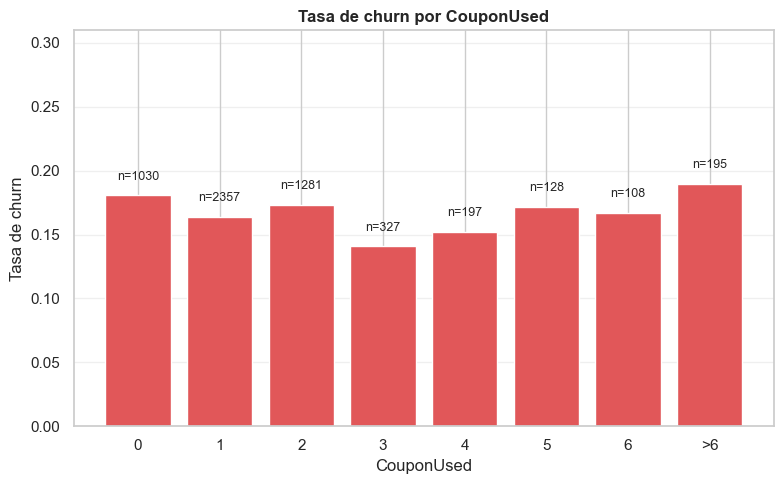

In [22]:
def plot_churn_rate_by_discrete_var(col, max_regular, title):
    plot_df = analysis_data_for(col).copy()
    plot_df[col] = plot_df[col].round().astype(int)

    # Agrupar valores altos
    plot_df[f"{col}_grupo"] = np.where(
        plot_df[col] > max_regular,
        f">{max_regular}",
        plot_df[col].astype(str)
    )

    # Orden correcto del eje x
    order = [str(i) for i in range(0, max_regular + 1)]
    order += [f">{max_regular}"]

    summary = (
        plot_df
        .groupby(f"{col}_grupo")
        .agg(
            churn_rate=("Churn", "mean"),
            n=("Churn", "size")
        )
        .reindex(order)
        .dropna()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    x = np.arange(len(summary))

    ax.bar(
        x,
        summary["churn_rate"],
        color=CHURN_COLORS[1],
        edgecolor="white"
    )

    # Etiquetas con n por categoría
    for i, row in summary.iterrows():
        ax.text(
            i,
            row["churn_rate"] + 0.01,
            f"n={int(row['n'])}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Tasa de churn")
    ax.set_ylim(0, min(1, summary["churn_rate"].max() + 0.12))
    ax.set_xticks(x)
    ax.set_xticklabels(summary[f"{col}_grupo"])
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_churn_rate_by_discrete_var(
    col="OrderCount",
    max_regular=8,
    title="Tasa de churn por OrderCount"
)

plot_churn_rate_by_discrete_var(
    col="CouponUsed",
    max_regular=6,
    title="Tasa de churn por CouponUsed"
)

In [23]:

transaction_vars = ["CashbackAmount", "OrderCount", "CouponUsed"]

pd.concat(
    [
        numeric_hypothesis_summary(df, col).assign(variable=col)
        for col in transaction_vars
    ],
    ignore_index=True
)

,grupo,n,media,mediana,p_value_mann_whitney,rank_biserial,interpretacion_efecto,variable
0,Sigue activo,4676,180.609,166.000,0.000,0.267,efecto medio,CashbackAmount
1,Se fue,947,160.321,150.000,0.000,0.267,efecto medio,CashbackAmount
2,Sigue activo,4676,3.103,2.000,0.009,0.051,efecto bajo,OrderCount
3,Se fue,947,2.876,2.000,0.009,0.051,efecto bajo,OrderCount
4,Sigue activo,4676,1.719,1.000,0.512,0.013,efecto bajo,CouponUsed
5,Se fue,947,1.707,1.000,0.512,0.013,efecto bajo,CouponUsed


**Interpretacion:** `CashbackAmount` muestra una diferencia relevante: quienes se fueron recibieron menos cashback en promedio. `OrderCount` y `CouponUsed` tienen diferencias mas chicas. Para negocio, cashback podria ser una palanca de retencion, aunque antes de recomendar campanas hay que separar causalidad de correlacion.

### H5: Algunos segmentos tienen mayor churn

**Logica de negocio:** no todos los clientes abandonan por los mismos motivos. Segmentar permite convertir el EDA en acciones comerciales mas concretas.

,variable,segmento,clientes,tasa_churn_%
7,PreferedOrderCat,Mobile Phone,2078,27.430
12,MaritalStatus,Single,1796,26.730
2,PreferredPaymentMode,Cash on Delivery,514,24.900
3,PreferredPaymentMode,E wallet,614,22.800
15,CityTier,3,1717,21.370
0,PreferredLoginDevice,Computer,1632,19.850
16,CityTier,2,242,19.830
18,Gender,Male,3379,17.730
4,PreferredPaymentMode,UPI,414,17.390
1,PreferredLoginDevice,Mobile Phone,3991,15.610


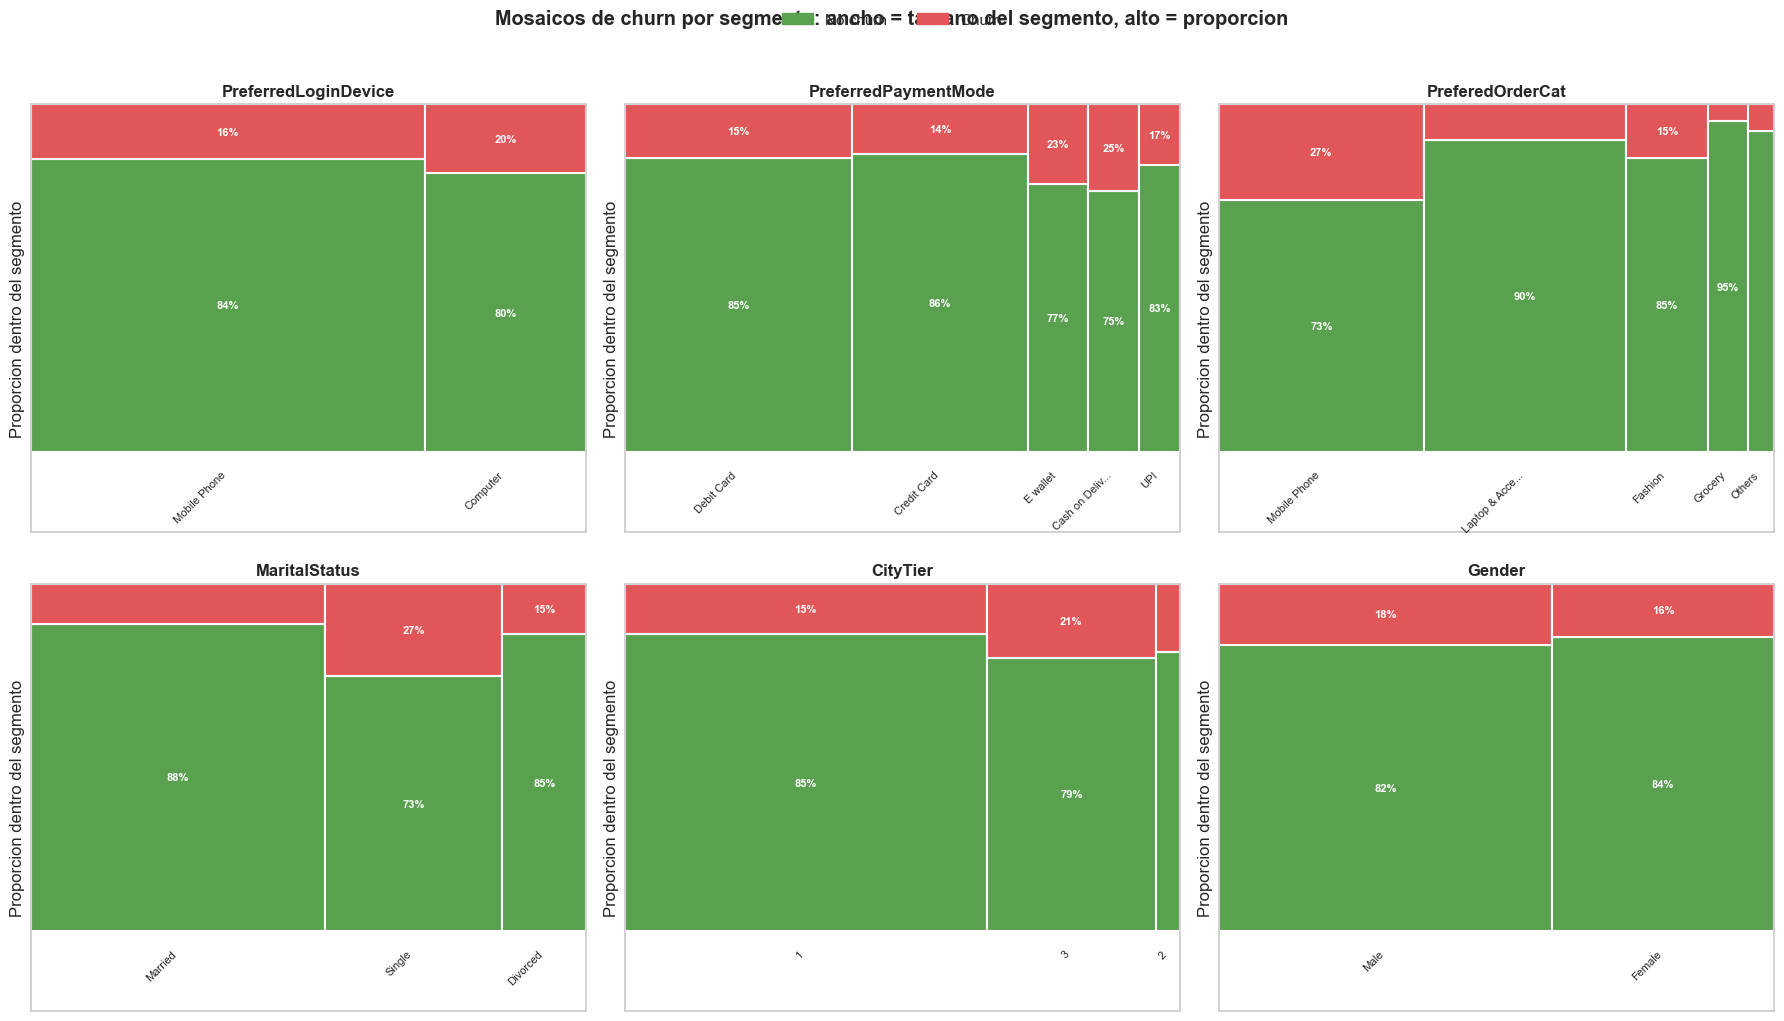

In [24]:
segment_vars = ["PreferredLoginDevice", "PreferredPaymentMode", "PreferedOrderCat", "MaritalStatus", "CityTier", "Gender"]


def plot_churn_mosaic(data, variable, ax):
    table = pd.crosstab(data[variable], data["Churn"])
    table = table.loc[table.sum(axis=1).sort_values(ascending=False).index]
    total = table.values.sum()
    x_start = 0
    for category, row in table.iterrows():
        width = row.sum() / total
        y_start = 0
        for churn_value in [0, 1]:
            height = row.get(churn_value, 0) / row.sum() if row.sum() else 0
            rect = plt.Rectangle(
                (x_start, y_start),
                width,
                height,
                facecolor=CHURN_COLORS[churn_value],
                edgecolor="white",
                linewidth=1.5,
            )
            ax.add_patch(rect)
            if width > 0.06 and height > 0.12:
                ax.text(
                    x_start + width / 2,
                    y_start + height / 2,
                    f"{height * 100:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                    weight="bold",
                )
            y_start += height
        label = str(category)
        if len(label) > 14:
            label = label[:13] + "..."
        ax.text(x_start + width / 2, -0.05, label, ha="right", va="top", rotation=45, fontsize=8)
        x_start += width
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.23, 1)
    ax.set_title(variable)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel("Proporcion dentro del segmento")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), segment_vars):
    plot_churn_mosaic(df_eda, col, ax)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=CHURN_COLORS[0], label="No churn"),
    plt.Rectangle((0, 0), 1, 1, color=CHURN_COLORS[1], label="Churn"),
]
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False)
plt.suptitle("Mosaicos de churn por segmento: ancho = tamano del segmento, alto = proporcion", y=1.02, fontweight="bold")
plt.tight_layout()

segment_summary = pd.concat(
    [categorical_churn_table(df_eda, col).reset_index().assign(variable=col).rename(columns={col: "segmento"}) for col in segment_vars],
    ignore_index=True,
)
segment_summary[["variable", "segmento", "clientes", "tasa_churn_%"]].sort_values("tasa_churn_%", ascending=False).head(15)

In [25]:
pd.concat([chi_square_test(df_eda, col) for col in segment_vars], ignore_index=True).sort_values("p_value")

,variable,chi2,p_value,dof,cramers_v,interpretacion_efecto
2,PreferedOrderCat,288.764,0.000,4,0.227,efecto medio
3,MaritalStatus,188.765,0.000,2,0.183,efecto medio
1,PreferredPaymentMode,51.795,0.000,4,0.096,efecto bajo
4,CityTier,40.843,0.000,2,0.085,efecto bajo
0,PreferredLoginDevice,14.587,0.000,1,0.051,efecto bajo
5,Gender,4.584,0.032,1,0.029,efecto bajo


**Interpretacion:** se observan diferencias por categoria de compra, estado civil, medio de pago y dispositivo. En particular, mobile y clientes solteros aparecen como segmentos con churn mas alto. Estos grupos pueden servir para priorizar analisis y acciones, pero no implican causalidad por si solos.

### Lectura especifica: SatisfactionScore

La satisfaccion es una variable clave porque parece obvia desde negocio, pero hay que validarla: no alcanza con asumir que menor satisfaccion implica mayor churn.

,SatisfactionScore,clientes,tasa_churn_%
0,1,1160,11.550
1,2,586,12.630
2,3,1695,17.170
3,4,1074,17.130
4,5,1108,23.830


,variable,chi2,p_value,dof,cramers_v,interpretacion_efecto
0,SatisfactionScore,69.401,0.000,4,0.111,efecto medio


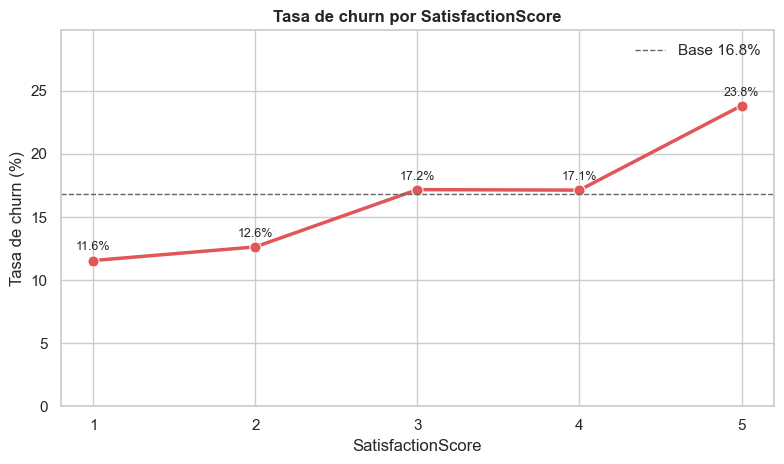

In [26]:
satisfaction_table = categorical_churn_table(df_eda, "SatisfactionScore").sort_index().reset_index()

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.lineplot(
    data=satisfaction_table,
    x="SatisfactionScore",
    y="tasa_churn_%",
    marker="o",
    color=CHURN_COLORS[1],
    linewidth=2.5,
    markersize=8,
    ax=ax,
)
baseline = df_eda["Churn"].mean() * 100
ax.axhline(baseline, color="#666666", linestyle="--", linewidth=1, label=f"Base {baseline:.1f}%")
for _, row in satisfaction_table.iterrows():
    ax.text(row["SatisfactionScore"], row["tasa_churn_%"] + 0.8, f"{row['tasa_churn_%']:.1f}%", ha="center", fontsize=9)
ax.set_title("Tasa de churn por SatisfactionScore")
ax.set_xlabel("SatisfactionScore")
ax.set_ylabel("Tasa de churn (%)")
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_ylim(0, max(satisfaction_table["tasa_churn_%"]) * 1.25)
ax.legend(frameon=False)
plt.tight_layout()

display(satisfaction_table[["SatisfactionScore", "clientes", "tasa_churn_%"]])
chi_square_test(df_eda, "SatisfactionScore")

**Interpretacion:** si la tasa de churn no baja de forma monotona a medida que sube la satisfaccion, entonces la relacion no es tan simple como "cliente menos satisfecho = cliente que se va". Para negocio, conviene cruzar satisfaction con `Complain`, `Tenure` y categoria de compra antes de convertirla en accion.

## 5.1. Variables adicionales a no perder de vista

La skill `ds-explorer` recomienda no declarar una variable como irrelevante sin mirarla al menos de una forma. Estas variables no eran las protagonistas de las hipotesis, pero cubren uso, logistica, complejidad del cliente y comportamiento de compra.

,grupo,n,media,mediana,p_value_mann_whitney,rank_biserial,interpretacion_efecto
0,Sigue activo,4676,15.257,14.000,0.000,-0.125,efecto medio
1,Se fue,947,16.868,14.000,0.000,-0.125,efecto medio


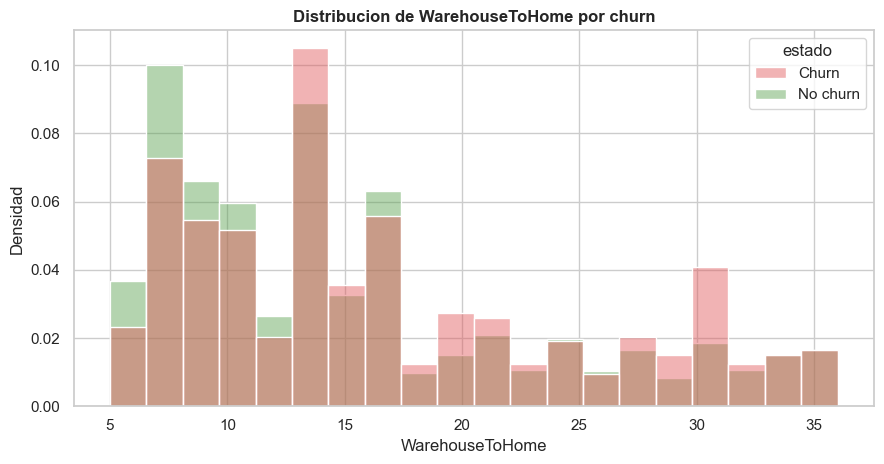

In [27]:
distance_df = analysis_data_for("WarehouseToHome").copy()
distance_df["estado"] = distance_df["Churn"].map(CHURN_LABELS)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.histplot(
    data=distance_df,
    x="WarehouseToHome",
    hue="estado",
    bins=20,
    stat="density",
    common_norm=False,
    palette={"No churn": CHURN_COLORS[0], "Churn": CHURN_COLORS[1]},
    alpha=0.45,
    ax=ax,
)
ax.set_title("Distribucion de WarehouseToHome por churn")
ax.set_xlabel("WarehouseToHome")
ax.set_ylabel("Densidad")
plt.tight_layout()

numeric_hypothesis_summary(df, "WarehouseToHome")

/var/folders/6z/2nkwfpvj5vdbpmc404rhvrsh0000gn/T/ipykernel_74370/299712713.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = data.groupby(variable, dropna=False)["Churn"].agg(clientes="count", tasa_churn="mean")


,grupo,n,media,mediana,p_value_mann_whitney,rank_biserial,interpretacion_efecto
0,Sigue activo,4676,15.736,15.000,0.069,0.037,efecto bajo
1,Se fue,947,15.626,15.000,0.069,0.037,efecto bajo


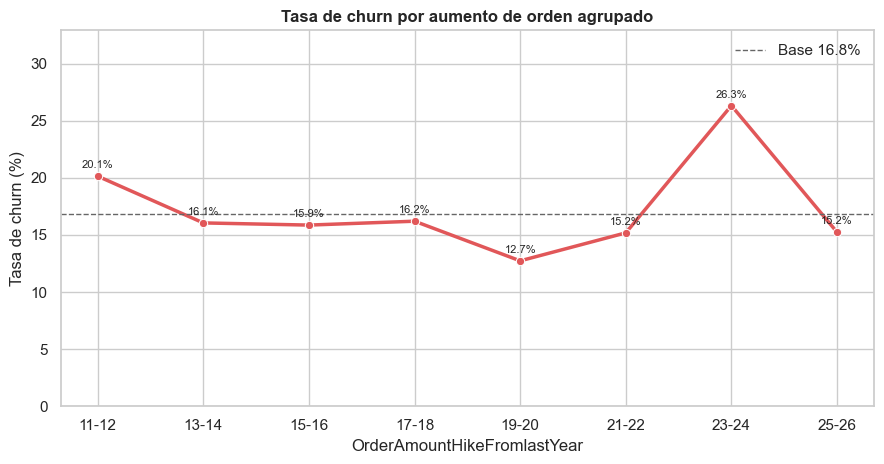

In [28]:
hike_df = df_eda.copy()
hike_df["OrderHikeGroup"] = pd.cut(
    hike_df["OrderAmountHikeFromlastYear"],
    bins=[10, 12, 14, 16, 18, 20, 22, 24, 26],
    labels=["11-12", "13-14", "15-16", "17-18", "19-20", "21-22", "23-24", "25-26"],
    include_lowest=True,
)
hike_table = categorical_churn_table(hike_df, "OrderHikeGroup").sort_index().reset_index()

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.lineplot(
    data=hike_table,
    x="OrderHikeGroup",
    y="tasa_churn_%",
    marker="o",
    color=CHURN_COLORS[1],
    linewidth=2.5,
    ax=ax,
)
baseline = df_eda["Churn"].mean() * 100
ax.axhline(baseline, color="#666666", linestyle="--", linewidth=1, label=f"Base {baseline:.1f}%")
for i, row in hike_table.iterrows():
    ax.text(i, row["tasa_churn_%"] + 0.7, f"{row['tasa_churn_%']:.1f}%", ha="center", fontsize=8)
ax.set_title("Tasa de churn por aumento de orden agrupado")
ax.set_xlabel("OrderAmountHikeFromlastYear")
ax.set_ylabel("Tasa de churn (%)")
ax.set_ylim(0, max(hike_table["tasa_churn_%"].max() * 1.25, baseline * 1.5))
ax.legend(frameon=False)
plt.tight_layout()

numeric_hypothesis_summary(df, "OrderAmountHikeFromlastYear")

,grupo,n,media,mediana,p_value_mann_whitney,rank_biserial,interpretacion_efecto
0,Sigue activo,4676,3.640,4.000,0.000,-0.147,efecto medio
1,Se fue,947,3.935,4.000,0.000,-0.147,efecto medio


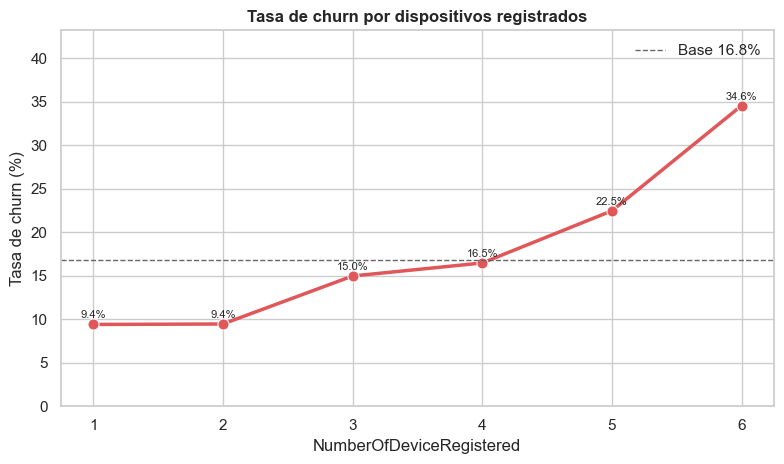

In [29]:
device_table = categorical_churn_table(df_eda, "NumberOfDeviceRegistered").sort_index().reset_index()

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.lineplot(
    data=device_table,
    x="NumberOfDeviceRegistered",
    y="tasa_churn_%",
    marker="o",
    color=CHURN_COLORS[1],
    linewidth=2.5,
    markersize=8,
    ax=ax,
)
baseline = df_eda["Churn"].mean() * 100
ax.axhline(baseline, color="#666666", linestyle="--", linewidth=1, label=f"Base {baseline:.1f}%")
for _, row in device_table.iterrows():
    ax.text(row["NumberOfDeviceRegistered"], row["tasa_churn_%"] + 0.7, f"{row['tasa_churn_%']:.1f}%", ha="center", fontsize=8)
ax.set_title("Tasa de churn por dispositivos registrados")
ax.set_xlabel("NumberOfDeviceRegistered")
ax.set_ylabel("Tasa de churn (%)")
ax.set_xticks(sorted(device_table["NumberOfDeviceRegistered"].unique()))
ax.set_ylim(0, max(device_table["tasa_churn_%"].max() * 1.25, baseline * 1.5))
ax.legend(frameon=False)
plt.tight_layout()

numeric_hypothesis_summary(df, "NumberOfDeviceRegistered")

/var/folders/6z/2nkwfpvj5vdbpmc404rhvrsh0000gn/T/ipykernel_74370/299712713.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = data.groupby(variable, dropna=False)["Churn"].agg(clientes="count", tasa_churn="mean")


,grupo,n,media,mediana,p_value_mann_whitney,rank_biserial,interpretacion_efecto
0,Sigue activo,4676,4.164,3.000,0.033,-0.043,efecto bajo
1,Se fue,947,4.465,3.000,0.033,-0.043,efecto bajo


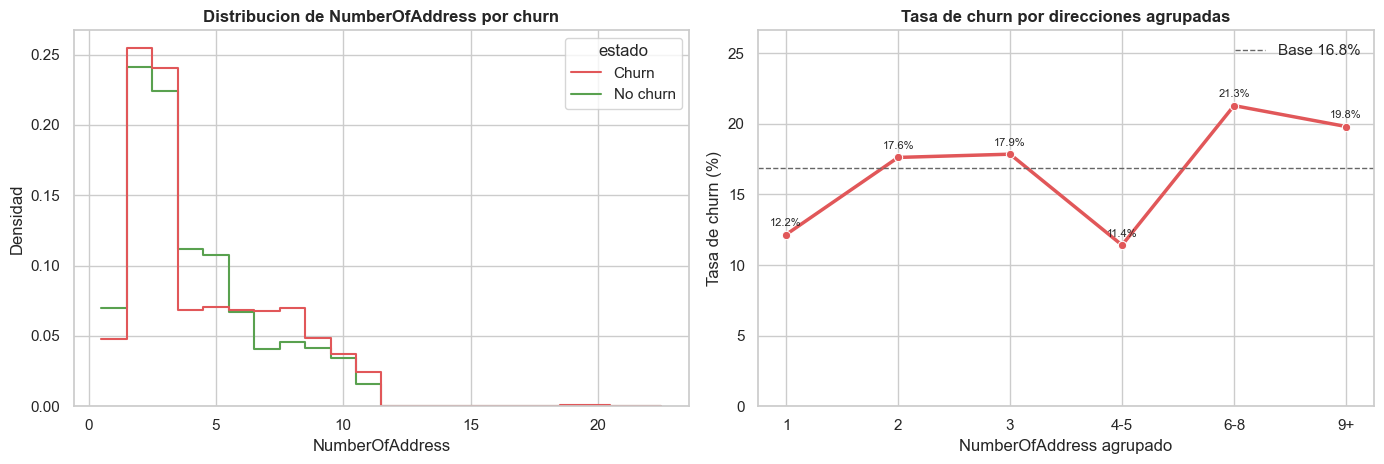

In [30]:
address_df = df_eda.copy()
address_df["estado"] = address_df["Churn"].map(CHURN_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.histplot(
    data=address_df,
    x="NumberOfAddress",
    hue="estado",
    discrete=True,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    palette={"No churn": CHURN_COLORS[0], "Churn": CHURN_COLORS[1]},
    ax=axes[0],
)
axes[0].set_title("Distribucion de NumberOfAddress por churn")
axes[0].set_xlabel("NumberOfAddress")
axes[0].set_ylabel("Densidad")

address_group_df = address_df.copy()
address_group_df["AddressGroup"] = pd.cut(
    address_group_df["NumberOfAddress"],
    bins=[0, 1, 2, 3, 5, 8, np.inf],
    labels=["1", "2", "3", "4-5", "6-8", "9+"],
    right=True,
)
address_table = categorical_churn_table(address_group_df, "AddressGroup").sort_index().reset_index()
sns.lineplot(
    data=address_table,
    x="AddressGroup",
    y="tasa_churn_%",
    marker="o",
    color=CHURN_COLORS[1],
    linewidth=2.5,
    ax=axes[1],
)
baseline = df_eda["Churn"].mean() * 100
axes[1].axhline(baseline, color="#666666", linestyle="--", linewidth=1, label=f"Base {baseline:.1f}%")
for i, row in address_table.iterrows():
    axes[1].text(i, row["tasa_churn_%"] + 0.6, f"{row['tasa_churn_%']:.1f}%", ha="center", fontsize=8)
axes[1].set_title("Tasa de churn por direcciones agrupadas")
axes[1].set_xlabel("NumberOfAddress agrupado")
axes[1].set_ylabel("Tasa de churn (%)")
axes[1].set_ylim(0, max(address_table["tasa_churn_%"].max() * 1.25, baseline * 1.5))
axes[1].legend(frameon=False)
plt.tight_layout()

numeric_hypothesis_summary(df, "NumberOfAddress")

In [31]:
additional_tests = pd.concat(
    [numeric_hypothesis_summary(df, col).assign(variable=col) for col in [
        "WarehouseToHome",
        "HourSpendOnApp",
        "OrderAmountHikeFromlastYear",
        "NumberOfDeviceRegistered",
        "NumberOfAddress",
    ]],
    ignore_index=True,
)
additional_tests

,grupo,n,media,mediana,p_value_mann_whitney,rank_biserial,interpretacion_efecto,variable
0,Sigue activo,4676,15.257,14.000,0.000,-0.125,efecto medio,WarehouseToHome
1,Se fue,947,16.868,14.000,0.000,-0.125,efecto medio,WarehouseToHome
2,Sigue activo,4676,2.916,3.000,0.612,-0.010,efecto bajo,HourSpendOnApp
3,Se fue,947,2.942,3.000,0.612,-0.010,efecto bajo,HourSpendOnApp
4,Sigue activo,4676,15.736,15.000,0.069,0.037,efecto bajo,OrderAmountHikeFromlastYear
5,Se fue,947,15.626,15.000,0.069,0.037,efecto bajo,OrderAmountHikeFromlastYear
6,Sigue activo,4676,3.640,4.000,0.000,-0.147,efecto medio,NumberOfDeviceRegistered
7,Se fue,947,3.935,4.000,0.000,-0.147,efecto medio,NumberOfDeviceRegistered
8,Sigue activo,4676,4.164,3.000,0.033,-0.043,efecto bajo,NumberOfAddress
9,Se fue,947,4.465,3.000,0.033,-0.043,efecto bajo,NumberOfAddress


**Lectura:** estas variables quedan revisadas como se?ales secundarias, cada una con un grafico propio para no mezclar escalas ni saturar la lectura. Distancia queda como distribucion; las variables discretas u ordinales se muestran como tasa de churn contra la linea base para que el desbalance no distorsione la interpretacion.

## 6. Correlaciones numericas

La correlacion ayuda a detectar relaciones lineales y variables que se mueven parecido. No prueba causalidad, pero orienta el modelado futuro.

,correlacion_con_churn
Churn,1.000
Tenure,-0.343
Complain,0.251
DaySinceLastOrder,-0.156
CashbackAmount,-0.154
NumberOfDeviceRegistered,0.108
SatisfactionScore,0.105
CityTier,0.085
WarehouseToHome,0.075
NumberOfAddress,0.044


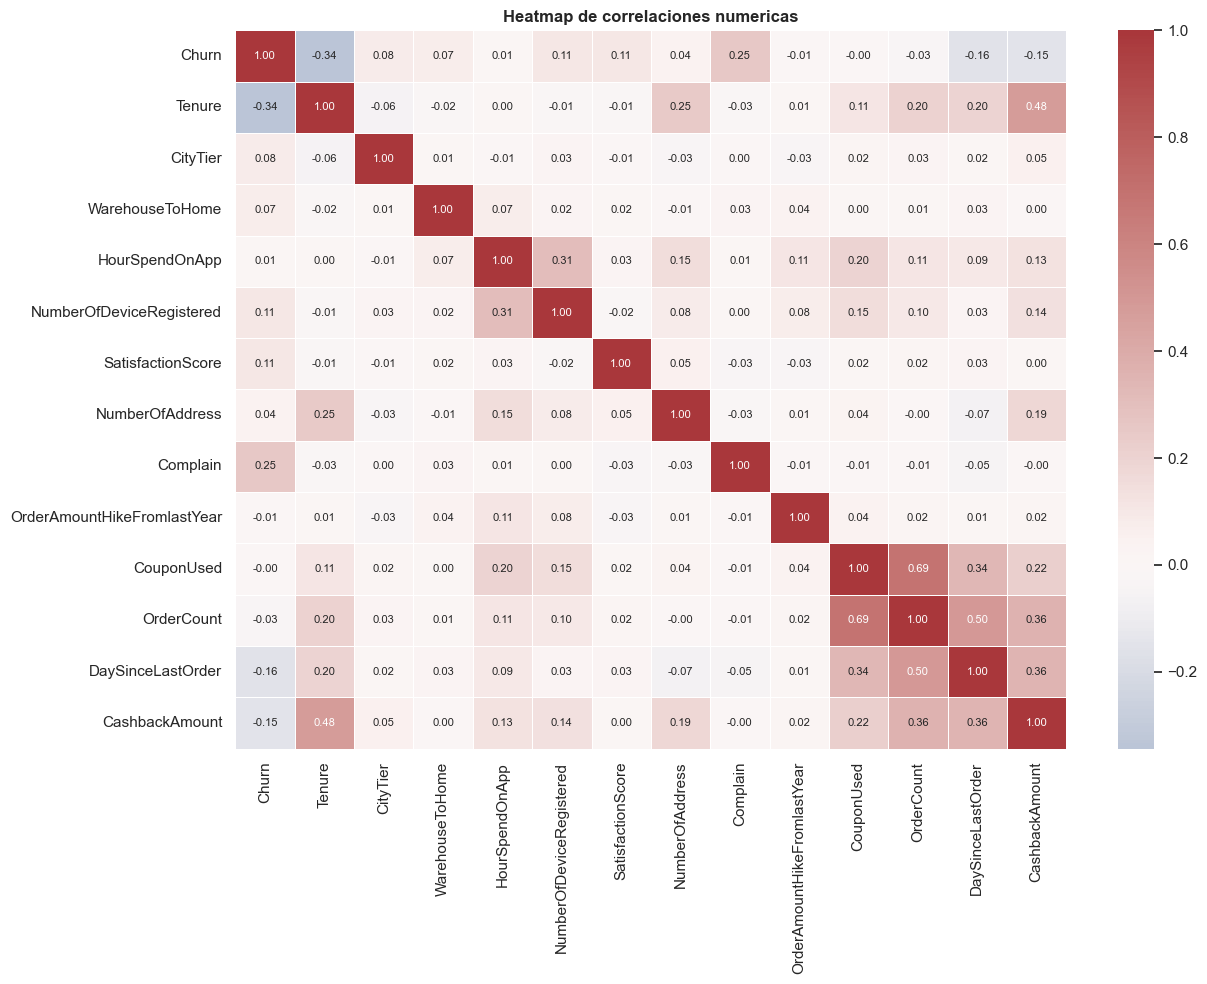

In [32]:
corr = df_eda[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 8},
    ax=ax,
)
ax.set_title("Heatmap de correlaciones numericas")
plt.tight_layout()

corr["Churn"].sort_values(key=lambda s: s.abs(), ascending=False).to_frame("correlacion_con_churn")

**Lectura:** las asociaciones mas fuertes con churn aparecen en `Tenure`, `Complain`, `CashbackAmount`, `NumberOfDeviceRegistered`, `SatisfactionScore` y `CityTier`. Algunas variables pueden estar relacionadas entre si y convendra revisarlas antes del modelado.

**Chequeo de cobertura:** ya miramos visualmente las variables principales y las secundarias (`WarehouseToHome`, `HourSpendOnApp`, `NumberOfDeviceRegistered`, `NumberOfAddress`, `OrderAmountHikeFromlastYear`). Lo que falta para la siguiente etapa no es mas EDA suelto, sino cruces priorizados y pipeline reproducible.

## 7. Tabla resumen de hallazgos

Esta tabla traduce el EDA a lenguaje accionable para negocio.

In [33]:
findings = pd.DataFrame([
    {
        "variable": "Tenure",
        "hallazgo": "Los clientes que churnean tienen mucha menor antiguedad promedio.",
        "lectura_de_negocio": "El riesgo parece concentrarse en etapas tempranas de la relacion.",
        "accion_sugerida": "Disenar acciones de onboarding y retencion para clientes nuevos.",
    },
    {
        "variable": "Complain",
        "hallazgo": "Quienes reclamaron tienen mayor tasa de churn.",
        "lectura_de_negocio": "La mala experiencia puede acelerar la salida.",
        "accion_sugerida": "Activar recuperacion de servicio despues de cada reclamo y revisar leakage temporal.",
    },
    {
        "variable": "DaySinceLastOrder",
        "hallazgo": "La relacion observada no confirma la intuicion de mayor inactividad = mayor churn.",
        "lectura_de_negocio": "La ventana temporal del dato puede no estar alineada con la definicion de baja.",
        "accion_sugerida": "Documentar riesgo temporal antes de usarla como predictor.",
    },
    {
        "variable": "CashbackAmount",
        "hallazgo": "Los clientes que se fueron recibieron menos cashback en promedio.",
        "lectura_de_negocio": "Los beneficios pueden estar asociados a mayor permanencia o mayor valor del cliente.",
        "accion_sugerida": "Evaluar campanas controladas de beneficios para segmentos de riesgo.",
    },
    {
        "variable": "Segmentos categoricos",
        "hallazgo": "Mobile, solteros y algunos medios de pago muestran churn mas alto.",
        "lectura_de_negocio": "El abandono no es homogeneo; hay segmentos donde priorizar.",
        "accion_sugerida": "Cruzar segmentos con tenure y reclamos para definir acciones comerciales concretas.",
    },
])

findings

,variable,hallazgo,lectura_de_negocio,accion_sugerida
0,Tenure,Los clientes que churnean tienen mucha menor a...,El riesgo parece concentrarse en etapas tempra...,Disenar acciones de onboarding y retencion par...
1,Complain,Quienes reclamaron tienen mayor tasa de churn.,La mala experiencia puede acelerar la salida.,Activar recuperacion de servicio despues de ca...
2,DaySinceLastOrder,La relacion observada no confirma la intuicion...,La ventana temporal del dato puede no estar al...,Documentar riesgo temporal antes de usarla com...
3,CashbackAmount,Los clientes que se fueron recibieron menos ca...,Los beneficios pueden estar asociados a mayor ...,Evaluar campanas controladas de beneficios par...
4,Segmentos categoricos,"Mobile, solteros y algunos medios de pago mues...",El abandono no es homogeneo; hay segmentos don...,Cruzar segmentos con tenure y reclamos para de...


## 8. Cierre ejecutivo

- La base tiene **5.630 clientes** y cerca de **16,8% de churn**, por lo que el problema esta desbalanceado.
- El patron mas claro es que los clientes con **menor antiguedad (`Tenure`)** tienen mas riesgo de irse.
- Los clientes que hicieron **reclamos (`Complain`)** churnean mas, pero esta variable debe revisarse por posible leakage temporal.
- `CashbackAmount` aparece asociado a permanencia: quienes se fueron recibieron menos cashback en promedio.
- Algunos segmentos, especialmente **mobile** y **solteros**, muestran tasas de churn superiores.
- `SatisfactionScore` debe interpretarse con cuidado: hay que validarlo con reclamos y antiguedad antes de asumir causalidad directa.
- `DaySinceLastOrder` no confirma la intuicion inicial; antes de modelar hay que entender mejor como fue medida.
- Para el EDA, `WarehouseToHome` y `CouponUsed` se imputaron por mediana; el resto de variables con nulos se imputaron comparando KNN vs regresion con estandarizacion previa.
- No se eliminan valores grandes automaticamente: solo se excluyen puntualmente 2 filas con `WarehouseToHome` extremo, 4 extremos de `Tenure` y el maximo de `DaySinceLastOrder` para que no distorsionen el EDA.
- Proxima etapa: separar train/test de forma estratificada y llevar esta limpieza a un pipeline reproducible sin tocar el dataset raw.

## 9. Checklist de validacion

- Dataset cargado con shape esperado: `5630 x 20`.
- `CustomerID` sin duplicados.
- Churn reportado: `948 / 5630 = 16,8%`.
- Cada hipotesis tiene grafico, tabla o test estadistico e interpretacion de negocio.
- El CSV original no se modifica; la normalizacion, imputacion y exclusiones puntuales de outliers se hacen solo en memoria.

In [34]:
assert df_raw.shape == (5630, 20)
assert df_raw["CustomerID"].duplicated().sum() == 0
assert df_raw["Churn"].sum() == 948
assert round(df_raw["Churn"].mean(), 4) == round(948 / 5630, 4)

print("Validaciones OK")
print(f"Churn rate: {df_raw['Churn'].mean() * 100:.2f}%")

Validaciones OK
Churn rate: 16.84%
